# Partie 2 - deuxieme modele (virus6.csv)
Modele : dV = V(2/3 - 4/3 P + X) dt + sigma dX, dP = P(-1+V) dt.
Figures dans figures_local/. Trois questions : evaluer sigma, proposer une EDS pour X, proposer une loi pour X_tau.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as scs
os.makedirs('figures_local', exist_ok=True)

def charge(f):
    d = pd.read_csv(f, header=None, names=['V', 'P']); return d['V'].values, d['P'].values
V, P = charge('virus6.csv'); V4, P4 = charge('virus4.csv'); N = len(V)
# pas de temps par l'equation (deterministe) des predateurs, masque sur le denominateur complet
dPd = np.diff(P); denom = P[:-1] * (-1 + V[:-1]); masque = np.abs(denom) > 0.001
dt = np.mean(dPd[masque] / denom[masque]); tau = N * dt; t = np.arange(N) * dt
print('dt = %.5f, tau = %.2f' % (dt, tau))
print('P descend sous 0.01 (predateurs eteints) a t = %.1f' % (t[np.argmax(P < 0.01)]))

dt = 0.01542, tau = 30.84
P descend sous 0.01 (predateurs eteints) a t = 28.0


### Donnees : victimes, predateurs (et extinction)

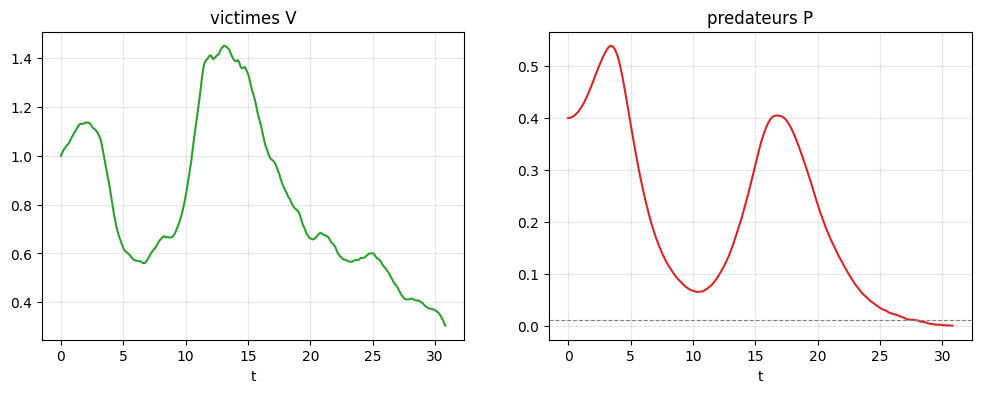

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t, V, color='tab:green'); ax[0].set_title('victimes V'); ax[0].set_xlabel('t'); ax[0].grid(alpha=.3)
ax[1].plot(t, P, color='tab:red'); ax[1].axhline(0.01, color='0.5', ls='--', lw=.8)
ax[1].set_title('predateurs P'); ax[1].set_xlabel('t'); ax[1].grid(alpha=.3)
plt.savefig('figures_local/p2_donnees.png', dpi=150, bbox_inches='tight'); plt.show()

## Question 1 - evaluation de sigma
Variation de V sur un pas = derive lisse V(...)dt + secousse aleatoire du virus sigma*dX.
Pour isoler la secousse, on prend la difference seconde de V, soit la difference de deux
variations consecutives : V[i+2]-2V[i+1]+V[i]. La derive lisse s'y annule, la secousse reste.
La somme des carres de ces differences secondes vaut environ 2 sigma^2 s^2 tau. On retranche
le cas sans bruit virus4 (reference du lisse), d'ou le produit sigma*s ; avec la diffusion du
virus s~0.05 (Partie 1) on en deduit sigma.

In [3]:
# difference seconde de V : V[i+2]-2V[i+1]+V[i] ; elle annule la derive lisse et isole les secousses
QV2 = np.sum(np.diff(V, 2)**2)        # somme des carres des differences secondes (virus6)
QV2_4 = np.sum(np.diff(V4, 2)**2)     # idem virus4 (sigma=0) : reference de la partie lisse a retrancher
sig_s = np.sqrt(max(QV2 - QV2_4, 0) / (2 * tau))   # = sigma * s
s_virus = 0.05                         # diffusion du virus, mesuree en Partie 1
sigma = sig_s / s_virus
print('sigma*s = %.2e  (somme ddV^2 : virus6=%.2e, virus4=%.2e)' % (sig_s, QV2, QV2_4))
print('avec s = %.2f  ->  sigma = %.3f' % (s_virus, sigma))

sigma*s = 9.00e-04  (somme ddV^2 : virus6=6.69e-05, virus4=1.69e-05)
avec s = 0.05  ->  sigma = 0.018


### Reconstruction du virus X
Comme sigma est petit, la reconstruction de la Partie 1 donne le virus apparent Z ~ X.

Z : Z0=-0.006  Z_fin=-1.107  moyenne=-0.434  ecart-type=0.224


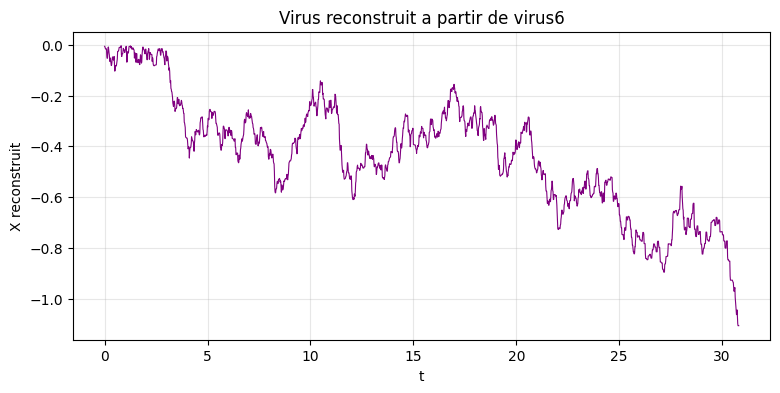

In [4]:
Z = np.diff(V) / (V[:-1] * dt) - 2/3 + 4/3 * P[:-1]; tZ = t[:-1]
print('Z : Z0=%.3f  Z_fin=%.3f  moyenne=%.3f  ecart-type=%.3f' % (Z[0], Z[-1], Z.mean(), Z.std()))
plt.figure(figsize=(9, 4))
plt.plot(tZ, Z, color='purple', lw=.8); plt.xlabel('t'); plt.ylabel('X reconstruit')
plt.title('Virus reconstruit a partir de virus6'); plt.grid(alpha=.3)
plt.savefig('figures_local/p2_virus.png', dpi=150, bbox_inches='tight'); plt.show()

## Question 2 - une EDS pour X
Le virus descend regulierement jusqu'a ~ -1 sans revenir vers un niveau : on propose un brownien avec
derive dX = nu dt + s dB (derive constante, pas de rappel). On estime nu et on teste les residus.

brownien avec derive : nu = -0.0357 , diffusion apparente = 0.110
residus : p-value normalite = 8.5e-24 , correlation consecutifs = 0.27


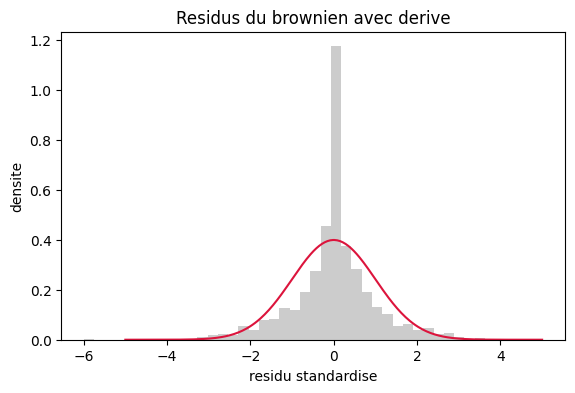

In [5]:
dZ = np.diff(Z)
nu = dZ.mean() / dt
s_app = dZ.std() / np.sqrt(dt)         # diffusion apparente (gonflee par le terme sigma dX)
print('brownien avec derive : nu = %.4f , diffusion apparente = %.3f' % (nu, s_app))
eps = (dZ - nu * dt) / (s_app * np.sqrt(dt))   # residus standardises, censes etre N(0,1) i.i.d.
print('residus : p-value normalite = %.1e , correlation consecutifs = %.2f'
      % (scs.kstest(eps, 'norm').pvalue, np.corrcoef(eps[:-1], eps[1:])[0, 1]))
plt.figure(figsize=(6.5, 4)); plt.hist(eps, bins=40, density=True, color='0.8')
g = np.linspace(-5, 5, 300); plt.plot(g, scs.norm.pdf(g), color='crimson')
plt.xlabel('residu standardise'); plt.ylabel('densite'); plt.title('Residus du brownien avec derive')
plt.savefig('figures_local/p2_residus.png', dpi=150, bbox_inches='tight'); plt.show()

## Question 3 - loi de X_tau
Sous dX = nu dt + s dB (lineaire, bruit brownien), X_tau = X_0 + nu tau + s B_tau est gaussienne :
X_tau ~ N(X_0 + nu tau, s^2 tau). On prend X_0 = 0 et la diffusion du virus s ~ 0.05.

In [6]:
X0 = 0.0
moy = X0 + nu * tau
var = s_virus**2 * tau
print('X_tau ~ N(moyenne = %.2f, variance = %.3f)  ecart-type = %.2f' % (moy, var, np.sqrt(var)))
print('observe : Z_fin = %.2f  (coherent avec la moyenne nu*tau)' % Z[-1])

X_tau ~ N(moyenne = -1.10, variance = 0.077)  ecart-type = 0.28
observe : Z_fin = -1.11  (coherent avec la moyenne nu*tau)
